In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
np.random.seed(42)

In [87]:
rfm = pd.read_csv('../data/rfm.csv', index_col='CustomerID', dtype={'CustomerID': 'string'})

# 1. Preprocessing for Clustering

Two things to do:
1. **Log transform** to reduce the right skew caused by the big wholesale customers.
2. **StandardScaler** so that all three columns have mean 0 and std 1. Without this, Monetary (in the thousands) would dominate Recency (in days) when distances are calculated.

I use the raw R, F, M values, not the 1-5 scores. I do not use CustomerID as a feature.

In [88]:
features = rfm[['Recency', 'Frequency', 'Monetary']]

print('Skewness before log:')
print(features.skew().round(2))

rfm_log = np.log1p(features)
print('\nSkewness after log:')
print(rfm_log.skew().round(2))

scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)
print('\nMean after scaling:', X.mean(axis=0).round(2))
print('Std after scaling :', X.std(axis=0).round(2))

Skewness before log:
Recency       1.25
Frequency    11.96
Monetary     21.51
dtype: float64

Skewness after log:
Recency     -0.38
Frequency    1.21
Monetary     0.37
dtype: float64

Mean after scaling: [-0.  0. -0.]
Std after scaling : [1. 1. 1.]


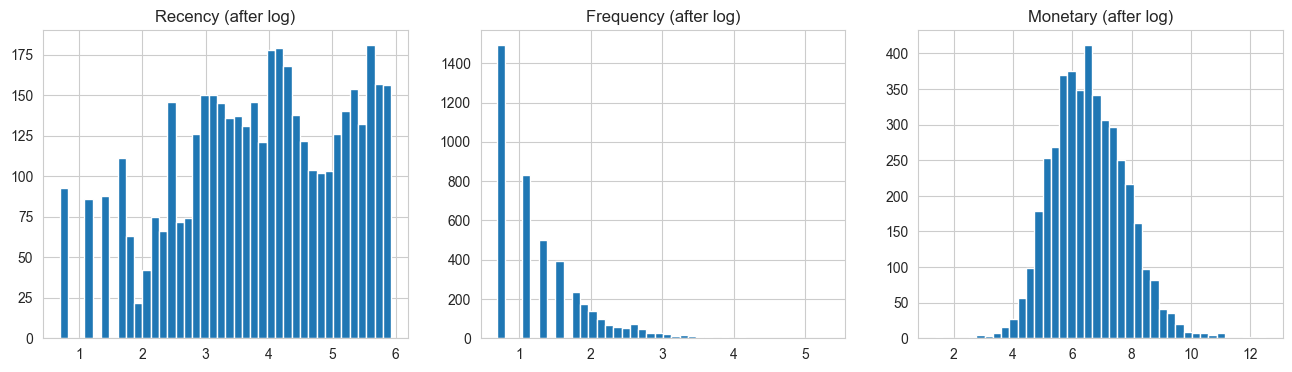

In [89]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, col in zip(ax, rfm_log.columns):
    rfm_log[col].hist(bins=40, ax=a)
    a.set_title(col + ' (after log)')
plt.show()

# 2. Clustering & Evaluation

## 2.1 K-Means: choosing K

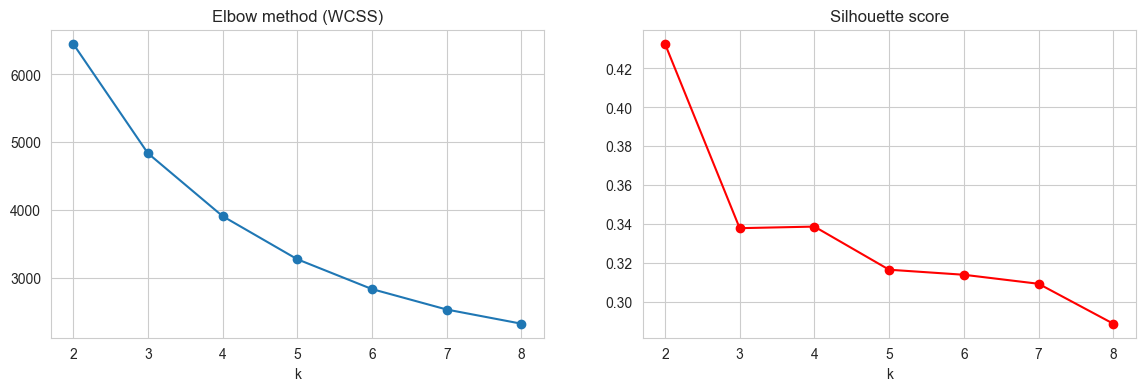

,WCSS,Silhouette
k,,
2,6453.864,0.433
3,4838.105,0.338
4,3909.690,0.339
5,3273.640,0.317
6,2833.342,0.314
7,2531.728,0.309
8,2322.487,0.289


In [90]:
res = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    res.append({'k': k, 'WCSS': km.inertia_, 'Silhouette': silhouette_score(X, km.labels_)})
res = pd.DataFrame(res).set_index('k')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(res.index, res['WCSS'], marker='o'); ax[0].set_title('Elbow method (WCSS)'); ax[0].set_xlabel('k')
ax[1].plot(res.index, res['Silhouette'], marker='o', color='red'); ax[1].set_title('Silhouette score'); ax[1].set_xlabel('k')
plt.show()
res.round(3)

In [101]:
# k = 2 often has the best silhouette, but it only splits active vs inactive customers, which is not enough
# for marketing. So I look for the best silhouette between 3 and 6 clusters.
best_k = res.loc[3:6, 'Silhouette'].idxmax()
print('Chosen k:', best_k, '| silhouette:', round(res.loc[best_k, 'Silhouette'], 3))

Chosen k: 4 | silhouette: 0.339


**Why k = 4?**
- The silhouette is highest at k = 2 (0.433), but that only splits customers into two big groups (probably active vs inactive), which is not enough for marketing actions.
- From k = 3 to k = 6 the silhouette is almost the same (0.338, 0.339, 0.317, 0.314). K = 3 and k = 4 are basically tied, so the silhouette alone cannot decide between them.
- The elbow plot does not show a sharp bend. WCSS keeps going down slowly (6454 to 4838 to 3910 to 3274), so I did not use the elbow alone.
- I chose k = 4 because it has the best silhouette in the range I allowed (3 to 6) and it gives marketing four groups to act on, which is still easy to manage.

The silhouette is only around 0.34, which is moderate. This is normal for customer data, because customers form one continuous cloud and not separate islands. So the clusters are a useful way to split customers, not perfect natural groups.

In [92]:
km_final = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X)
rfm['Cluster'] = km_final.labels_
print(rfm['Cluster'].value_counts().sort_index())

Cluster
0     829
1     685
2    1621
3    1185
Name: count, dtype: int64


## 2.2 Hierarchical clustering (on a sample)

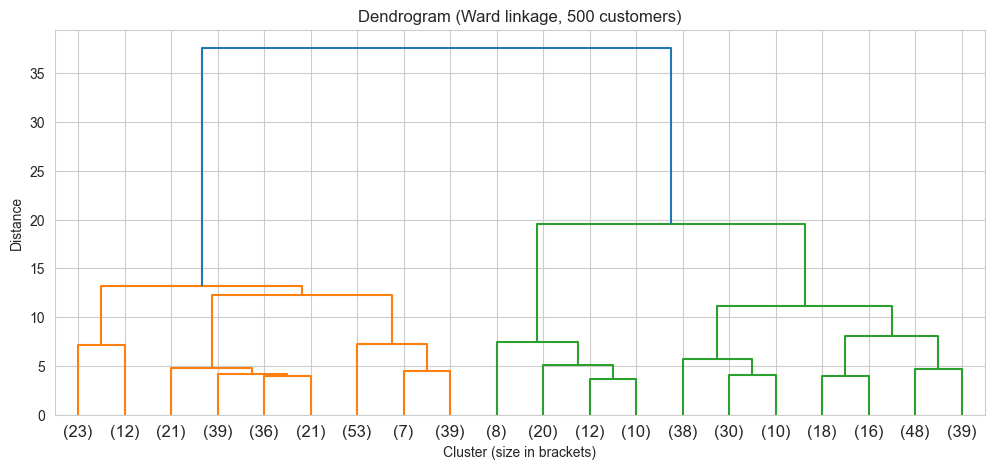

Hierarchical silhouette (sample): 0.333
K-Means silhouette (same sample): 0.342


In [93]:
idx = np.random.choice(len(X), size=min(500, len(X)), replace=False)
X_sample = X[idx]

Z = linkage(X_sample, method='ward')
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=20)
plt.title('Dendrogram (Ward linkage, 500 customers)')
plt.xlabel('Cluster (size in brackets)')
plt.ylabel('Distance')
plt.show()

hc = AgglomerativeClustering(n_clusters=best_k, linkage='ward').fit(X_sample)
km_sample = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X_sample)
print('Hierarchical silhouette (sample):', round(silhouette_score(X_sample, hc.labels_), 3))
print('K-Means silhouette (same sample):', round(silhouette_score(X_sample, km_sample.labels_), 3))

On the same sample of 500 customers, hierarchical clustering gets a silhouette of 0.333 and K-Means gets 0.342. They are very close, so both methods find a similar structure. K-Means is slightly better and much faster on all the customers, so I keep it.

## 2.3 DBSCAN (to find outliers)

In [94]:
db = DBSCAN(eps=0.5, min_samples=10).fit(X)
labels_db = db.labels_

n_noise = (labels_db == -1).sum()
print('Clusters found by DBSCAN:', len(set(labels_db)) - (1 if -1 in labels_db else 0))
print('Outliers (noise):', n_noise, f'({n_noise / len(X) * 100:.1f}%)')

rfm['DBSCAN_Outlier'] = (labels_db == -1)
print('\nAverage R, F, M of outliers vs the rest:')
rfm.groupby('DBSCAN_Outlier')[['Recency', 'Frequency', 'Monetary']].mean().round(1)

Clusters found by DBSCAN: 2
Outliers (noise): 80 (1.9%)

Average R, F, M of outliers vs the rest:


,Recency,Frequency,Monetary
DBSCAN_Outlier,,,
False,93.2,3.8,1357.8
True,55.8,28.6,31492.0


DBSCAN found 2 clusters and marked 80 customers (1.9%) as outliers. It does not give me the 4 actionable groups I need, because it only separates the data into 2 big clouds. Its useful part is the outliers: these 80 customers behave very differently from everyone else, so they should be looked at manually (for example as key accounts).

### 2.4 Comparison

| Algorithm | Result | Conclusion |
|---|---|---|
| K-Means | Silhouette 0.339 on all customers (0.342 on the sample), k = 4 | **I use this one.** Fast, easy to explain and gives 4 groups for marketing. |
| Hierarchical | Silhouette 0.333 on a sample of 500 | Similar result to K-Means, but slow on big data, so only used to check. |
| DBSCAN | 2 clusters and 80 outliers (1.9%) | Not good for segments, but useful to find extreme customers. |

# 3. Segment Profiling

In [95]:
profile = rfm.groupby('Cluster').agg(
    Customers=('Recency', 'size'),
    Recency_mean=('Recency', 'mean'),
    Frequency_mean=('Frequency', 'mean'),
    Monetary_mean=('Monetary', 'mean'),
    Recency_median=('Recency', 'median'),
    Frequency_median=('Frequency', 'median'),
    Monetary_median=('Monetary', 'median'),
    Revenue=('Monetary', 'sum'),
    UK_share=('Is_UK', 'mean'))
profile['%Customers'] = profile['Customers'] / profile['Customers'].sum() * 100
profile['%Revenue'] = profile['Revenue'] / profile['Revenue'].sum() * 100
profile.round(1)

,Customers,Recency_mean,Frequency_mean,Monetary_mean,Recency_median,Frequency_median,Monetary_median,Revenue,UK_share,%Customers,%Revenue
Cluster,,,,,,,,,,,
0,829,18.1,2.1,527.0,17.0,2.0,450.3,436877.3,0.9,19.2,5.3
1,685,11.8,14.0,7741.3,8.0,10.0,3623.0,5302773.3,0.9,15.9,64.1
2,1621,183.0,1.3,342.0,177.0,1.0,290.3,554314.4,0.9,37.5,6.7
3,1185,67.5,4.2,1672.8,52.0,4.0,1315.7,1982308.3,0.9,27.4,24.0


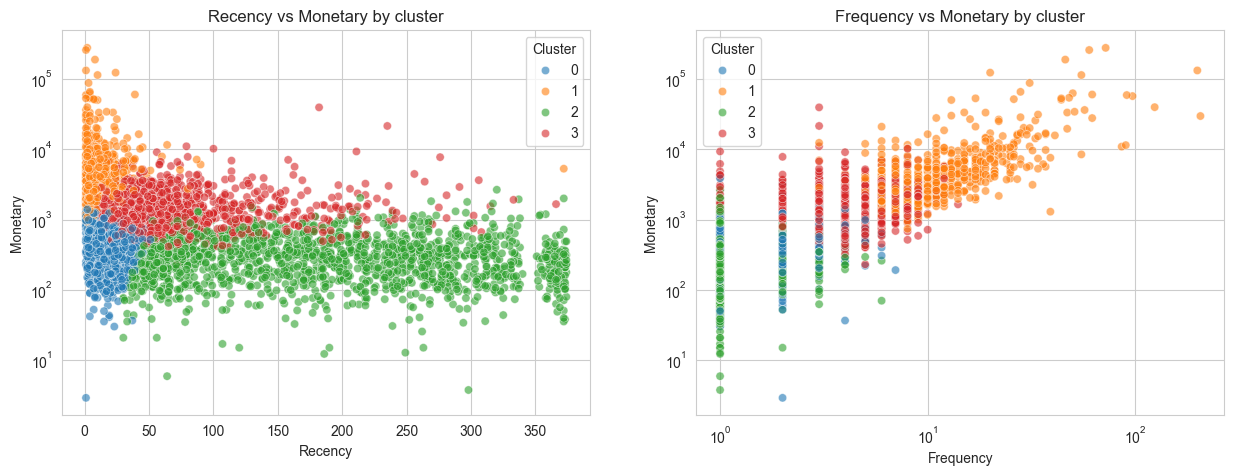

In [96]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='tab10', alpha=0.6, ax=ax[0])
ax[0].set_yscale('log'); ax[0].set_title('Recency vs Monetary by cluster')
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='tab10', alpha=0.6, ax=ax[1])
ax[1].set_xscale('log'); ax[1].set_yscale('log'); ax[1].set_title('Frequency vs Monetary by cluster')
plt.show()

In [97]:
# I give each cluster a name using its medians compared to all customers.
# I do this with rules so the names come from the numbers, and I check them myself after.
med = rfm[['Recency', 'Frequency', 'Monetary']].median()
q75 = rfm[['Recency', 'Frequency', 'Monetary']].quantile(0.75)

def name_cluster(row):
    r_good = row['Recency_median'] <= med['Recency']        # low recency = bought recently
    f_high = row['Frequency_median'] >= med['Frequency']
    m_high = row['Monetary_median'] >= med['Monetary']
    if r_good and row['Frequency_median'] >= q75['Frequency'] and row['Monetary_median'] >= q75['Monetary']:
        return 'Champions'
    elif r_good and f_high and m_high:
        return 'Loyal Customers'
    elif (not r_good) and f_high and m_high:
        return 'At-Risk High-Value'
    elif r_good and (not f_high) and (not m_high):
        return 'New / Low-Spend Recent'
    elif (not r_good) and (not f_high) and (not m_high):
        return 'Dormant Low-Value'
    else:
        return 'Mid-Value / Occasional'

profile['Segment'] = [name_cluster(r) + f' (C{i})' for i, r in profile.iterrows()]
rfm['Segment'] = rfm['Cluster'].map(profile['Segment'])

profile[['Segment', 'Customers', '%Customers', '%Revenue', 'Recency_median', 'Frequency_median', 'Monetary_median']].round(1)

,Segment,Customers,%Customers,%Revenue,Recency_median,Frequency_median,Monetary_median
Cluster,,,,,,,
0,Mid-Value / Occasional (C0),829,19.2,5.3,17.0,2.0,450.3
1,Champions (C1),685,15.9,64.1,8.0,10.0,3623.0
2,Dormant Low-Value (C2),1621,37.5,6.7,177.0,1.0,290.3
3,At-Risk High-Value (C3),1185,27.4,24.0,52.0,4.0,1315.7


In [98]:
# how do the clusters compare with the rule based RFM groups?
pd.crosstab(rfm['Segment'], rfm['RFM_Group'])

RFM_Group,At-Risk High-Value,Champions,Lost / Low-Value,Loyal Customers,Needs Attention,New Inflow
Segment,,,,,,
At-Risk High-Value (C3),348,251,40,482,54,10
Champions (C1),5,648,0,32,0,0
Dormant Low-Value (C2),108,0,1032,46,431,4
Mid-Value / Occasional (C0),0,41,0,436,57,295


# 4. Business Recommendations

Each cluster above gets an action depending on its name:

| Segment type | What the data shows | Action |
|---|---|---|
| **Champions** | Recent, frequent and high spending | Loyalty perks, early access to new products and referral rewards. Do not over-discount them, they already buy. |
| **Loyal Customers** | Regular buyers with good spending | Cross-sell related products and offer bundles or volume deals. |
| **At-Risk High-Value** | Used to spend a lot and often, but have not bought for a long time | Send a direct win-back email with a strong offer quickly, since they are worth a lot of revenue. |
| **New / Low-Spend Recent** | Bought recently, few orders, low spend | Welcome series with a small discount on a second purchase. |
| **Dormant Low-Value** | Long time since last purchase, low frequency and spend | Cheap automated campaigns only (for example one reactivation email), do not spend much money here. |
| **Mid-Value / Occasional** | In the middle on all three | Send seasonal reminders, especially before the Q4 peak, and try to move them towards loyal. |

**Other actions from the EDA**
1. Prepare stock and campaigns before September, because Q4 is the strongest season.
2. Send emails and ads around midday on weekdays, and do server maintenance at night.
3. Review the dead stock list and decide on clearance, bundles or stop re-ordering.
4. Look at the customers and products with the most returns to find the cause.
5. The business is too dependent on the UK, so grow the top international markets (especially those with few customers but high revenue).
6. Give the very large buyers (wholesale type) a separate account management or price list.

In [99]:
summary = profile[['Segment', 'Customers', '%Customers', '%Revenue']].round(1)
summary.sort_values('%Revenue', ascending=False)

,Segment,Customers,%Customers,%Revenue
Cluster,,,,
1,Champions (C1),685,15.9,64.1
3,At-Risk High-Value (C3),1185,27.4,24.0
2,Dormant Low-Value (C2),1621,37.5,6.7
0,Mid-Value / Occasional (C0),829,19.2,5.3


# 5. Limitations & Next Steps

**Limitations**
- The data covers only about one year, so I cannot be sure the seasonality repeats every year. The last month (Dec 2011) is incomplete.
- Guest customers (no CustomerID) are excluded from RFM and clustering.
- I did not link each return to its original invoice, I only subtracted the returns from the revenue.
- The silhouette score is moderate, so the clusters overlap a bit. Segments are a practical tool, not perfect natural groups.
- The data is descriptive. I can say what customers did, not why. For example I cannot say that a discount **causes** more purchases.
- We do not know costs or profit, only revenue, so a high revenue customer is not necessarily the most profitable one.
- The "wholesale" label is my guess based on basket size, not something confirmed in the data.

**Next steps**
- Get more years of data to check seasonality.
- Add product category and profit margin.
- Test the campaigns (A/B test) to see if the actions really work.
- Try to predict churn with a model and track how customers move between segments over time.

# 6. Final Conclusion

In [100]:
top10 = rfm['Monetary'].sort_values(ascending=False).head(int(len(rfm) * 0.1)).sum() / rfm['Monetary'].sum()

print(f"Customers segmented: {len(rfm)}")
print(f"Number of clusters chosen: {best_k}")
print(f"UK customers: {rfm['Is_UK'].mean()*100:.1f}% of segmented customers")
print(f"Top 10% of customers make {top10*100:.1f}% of net revenue")

Customers segmented: 4320
Number of clusters chosen: 4
UK customers: 90.4% of segmented customers
Top 10% of customers make 60.1% of net revenue
